<a href="https://colab.research.google.com/github/gnganesh99/NN_Error/blob/ayush_dev/notebooks/STM/stm_multiscale_train_size_variance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Installs on colab
def running_on_colab():
    try:
        import google.colab  # type: ignore
        return True
    except ImportError:
        return False

if running_on_colab():
    print("Running on Colab. Installing dependencies...")
    !pip install -q atomai neuraloperator ipympl ipywidgets hoffmanstmpy

    from google.colab import output
    output.enable_custom_widget_manager()

    !git clone -b ayush_dev --single-branch https://github.com/gnganesh99/NN_Error.git
    %cd NN_Error

    print("Colab setup complete.")

In [2]:
import sys
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset
import os
from scipy.ndimage import zoom


try:
    get_ipython().run_line_magic("matplotlib", "widget")
except (ValueError, RuntimeError):
    get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt


# Make package and notebook-local helper modules importable whether this starts in repo root or notebooks/
repo_root = Path.cwd() if (Path.cwd() / "src" / "nnerror").exists() else Path.cwd().parent.parent
src_root = str((repo_root / "src").resolve())
nb_root = str((repo_root / "notebooks"/"STM").resolve())
for import_root in (src_root, nb_root):
    if import_root not in sys.path:
        sys.path.insert(0, import_root)




from nnerror.networks import FNO_im2spec, CustomDecoder, im2spec, FNO_im2spec_attn, im2spec_attn
from nnerror.training_functions import err_estimation, train_model, predict_spectra, norm_0to1, predict_posterior, append_training_set
from nnerror.plot_functions import plot_only_training_loss, plot_training_loss, \
    plot_error_prediction, plot_spectra, plot_error_prediction_3d, plot_scale_slider, plot_latent_space, cluster_latent_space, plot_latent_distribution, plot_scale_specific_error_and_acquisition_maps
from nnerror.utils import append_multiscale_data, edges_zeroed_image, interpolated_center_crop, paired_images_spectra_1
from mpl_toolkits.axes_grid1 import make_axes_locatable



In [3]:
from sklearn.model_selection import train_test_split

In [4]:
from stm_utils import Sxm_Image
from CITS_Class import CITS_Analysis


# Functions


In [5]:
class Norm_G:
    """Gaussian normalization using mean and standard deviation."""

    def __init__(self, data=None, mean=None, std=None, axis=0, eps=1e-8):
        self.data = data
        self.axis = axis
        self.eps = eps

        if data is not None:
            self.mean = np.mean(data, axis=axis, keepdims=True)
            self.std = np.std(data, axis=axis, keepdims=True)
        elif mean is not None and std is not None:
            self.mean = mean
            self.std = std
        else:
            raise ValueError("Either data or both mean and std must be provided.")

        self.std = np.where(self.std < eps, eps, self.std)

    def normalize(self, data=None):
        """Normalize data using stored mean and std."""
        if data is None:
            data = self.data
        return (data - self.mean) / self.std

    def denormalize(self, normalized_data):
        """Denormalize data using stored mean and std."""
        return normalized_data * self.std + self.mean
    

class Norm_0to1:
    """Normalization to the range [0, 1]."""

    def __init__(self, data=None, min_val=None, max_val=None, axis=0, eps=1e-8):
        self.data = data
        self.axis = axis
        self.eps = eps

        if data is not None:
            self.min_val = np.min(data, axis=axis, keepdims=True)
            self.max_val = np.max(data, axis=axis, keepdims=True)
        elif min_val is not None and max_val is not None:
            self.min_val = min_val
            self.max_val = max_val
        else:
            raise ValueError("Either data or both min_val and max_val must be provided.")

        self.data_range = np.where(
            (self.max_val - self.min_val) < eps,
            eps,
            self.max_val - self.min_val
        )

    def normalize(self, data=None):
        """Normalize data using stored min and max."""
        if data is None:
            if self.data is None:
                raise ValueError("No data provided to normalize.")
            data = self.data

        return (data - self.min_val) / self.data_range

    def denormalize(self, normalized_data):
        """Denormalize data using stored min and max."""
        return normalized_data * self.data_range + self.min_val

In [6]:
def split_augment(train_size, images, spectra, swap_coordinates, WS_init, WS, d_WS, append_image_type, random_state = 42):

  images_train, images_test, spectra_train, spectra_test, s_coords_train, s_coords_test = train_test_split(
  images, spectra, swap_coordinates, train_size = train_size, random_state=random_state)



  images_tr_aug, spectra_tr_aug, _ = append_multiscale_data(images_train, spectra_train, scales=np.arange(WS_init, WS, d_WS),
                                                              coordinates=s_coords_train,
                                                              append_image_type=append_image_type)



  images_test_aug, spectra_test_aug, _ = append_multiscale_data(images_test, spectra_test, scales=np.arange(WS_init, WS, d_WS),
                                                              coordinates=s_coords_test,
                                                              append_image_type=append_image_type)

  return images_tr_aug, images_test_aug, spectra_tr_aug, spectra_test_aug

In [7]:
def get_model(model_type, in_dim, out_dim, latent_dim = 3, device = None):
    # ----------------------------
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if model_type == "im2spec":
        model = im2spec(feature_size=in_dim, target_size=out_dim, latent_dim=latent_dim).to(device)

    elif model_type == "FNO":
        model = FNO_im2spec(
            target_size=out_dim,
            latent_dim=latent_dim,
            hidden_channels=32,
            n_modes=(16, 16),
            n_layers=4,
        ).to(device)

    elif model_type == "im2spec_attn":
        model = im2spec_attn(feature_size=in_dim, target_size=out_dim, latent_dim=latent_dim).to(device)
    elif model_type == "FNO_attn":
        model = FNO_im2spec_attn(
            target_size=out_dim,
            latent_dim=latent_dim,
            hidden_channels=32,
            n_modes=(16, 16),
            n_layers=4,
        ).to(device)

    else:
        raise ValueError(f"Unknown model type: {model_type}")
    
    return model

# Get data

In [8]:
data_folder = r"data/large_area" if not running_on_colab() else r"notebooks/STM/data/large_area"

img_sxm = os.path.join(data_folder, "EnZn2As2017.sxm")
spectra_sxm = os.path.join(data_folder, "EuZn2As2003.3ds")
#Get the morphology image
full_image = Sxm_Image(img_sxm).image()
full_image = norm_0to1(full_image)

#Get the current spectra
cits_obj = CITS_Analysis(spectra_sxm)
hyperspectra = cits_obj.current

full_image.shape, hyperspectra.shape

File import successful.


((512, 512), (80, 250, 121))

In [9]:
WS = 32
WS_init = 4
d_WS = 4

(1024, 32, 32) (1024, 121) (1024, 2)
[30. 30.]


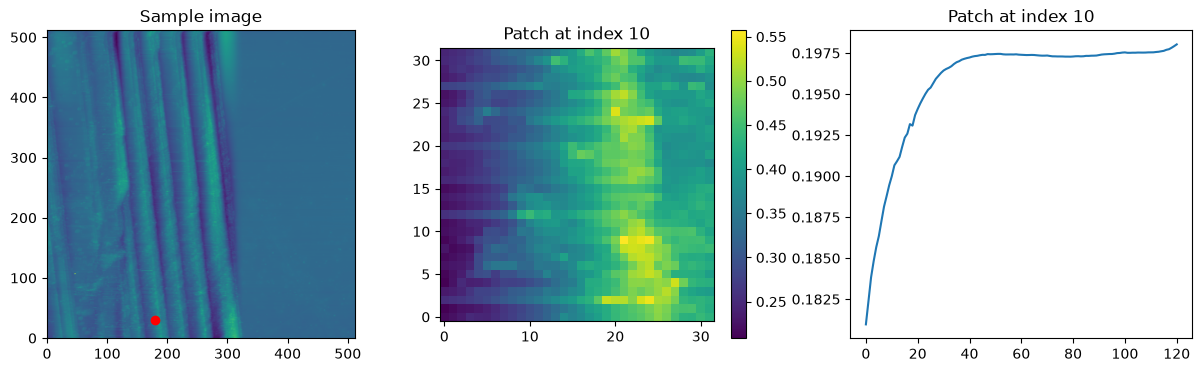

In [18]:


images, spectra, coordinates = paired_images_spectra_1(full_image, cits_obj, hyperspectra, window_size = WS,
                                                       coordinate_step = 15, image_norm=False, spectra_norm = False)

print(images.shape, spectra.shape, coordinates.shape)

print(coordinates[0])
fig, ax = plt.subplots(1, 3, figsize = (15, 4))


idx = 10

ax[0].imshow(full_image, origin = 'lower')
ax[0].scatter(coordinates[idx, 1], coordinates[idx, 0], c ="r")
ax[0].set_title("Sample image")


im = ax[1].imshow(images[idx], origin = 'lower')
fig.colorbar(im, ax=ax[1])
ax[1].set_title(f"Patch at index {idx}")
ax[2].plot(spectra[idx])
ax[2].set_title(f"Patch at index {idx}")

plt.show()

In [19]:
# coordinates are reversed.
swap_coordinates = coordinates.copy()
swap_coordinates = swap_coordinates[:, [1, 0]]
swap_coordinates.shape

(1024, 2)

In [20]:
images_all = images.copy()
spectra_all = spectra.copy()
swap_coordinates_all = swap_coordinates.copy()

# Variance with train size

In [21]:

n_epochs_im2spec = 5
n_epochs_error = 5
error_type = "L1" # "L1", "L2", or "cos"
model_type = 'FNO'  # 'im2spec', 'FNO', 'im2spec_attn', 'FNO_attn'
latent_dim = 5
append_image_type = "interpolate" if model_type == 'FNO' or model_type == 'FNO_attn' else "pad"  # Use "interpolate" for im2spec, "pad" for FNO
use_swa = True
last_swa_epochs = 100


Testing with test size: 0.1
Augmented images shape: (816, 32, 32), Augmented spectra shape: (816, 121), Augmented coordinates shape: (816, 3)
Augmented images shape: (7376, 32, 32), Augmented spectra shape: (7376, 121), Augmented coordinates shape: (7376, 3)


 20%|██        | 1/5 [00:39<02:38, 39.51s/it, train_loss=0.0368, val_loss=0.0291]

SWA triggered at epoch 0


100%|██████████| 5/5 [02:48<00:00, 33.78s/it, train_loss=0.0019, val_loss=0.0027]


  Error targets train shape: (816, 1)
  Error targets test shape: (7376, 1)
  Latent dimension for error model: 5


 20%|██        | 1/5 [00:04<00:18,  4.55s/it, train_loss=0.1655, val_loss=0.1369]

SWA triggered at epoch 0


100%|██████████| 5/5 [00:21<00:00,  4.39s/it, train_loss=0.0848, val_loss=0.1339]


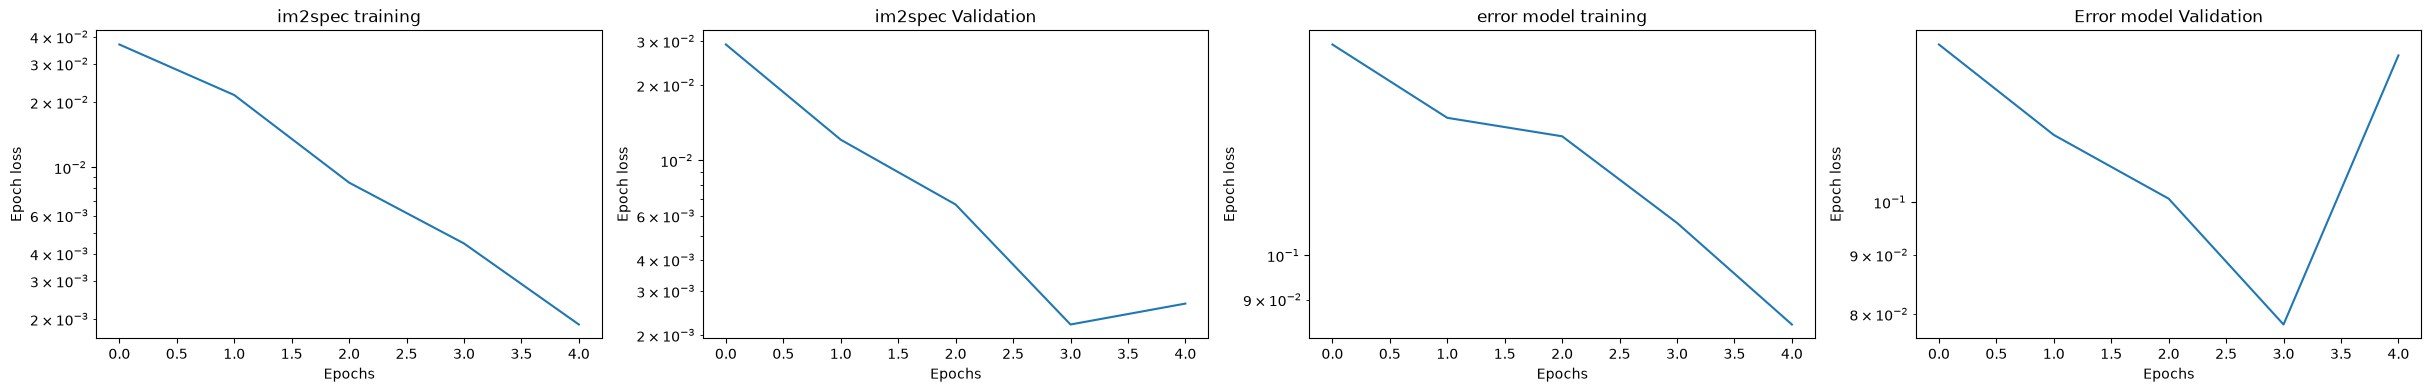


Testing with test size: 0.4
Augmented images shape: (3272, 32, 32), Augmented spectra shape: (3272, 121), Augmented coordinates shape: (3272, 3)
Augmented images shape: (4920, 32, 32), Augmented spectra shape: (4920, 121), Augmented coordinates shape: (4920, 3)


 20%|██        | 1/5 [00:34<02:19, 34.83s/it, train_loss=0.0416, val_loss=0.0322]

SWA triggered at epoch 0


100%|██████████| 5/5 [03:03<00:00, 36.69s/it, train_loss=0.0032, val_loss=0.0020]


  Error targets train shape: (3272, 1)
  Error targets test shape: (4920, 1)
  Latent dimension for error model: 5


 20%|██        | 1/5 [00:19<01:16, 19.04s/it, train_loss=0.0278, val_loss=0.0310]

SWA triggered at epoch 0


100%|██████████| 5/5 [01:40<00:00, 20.14s/it, train_loss=0.0189, val_loss=0.0316]


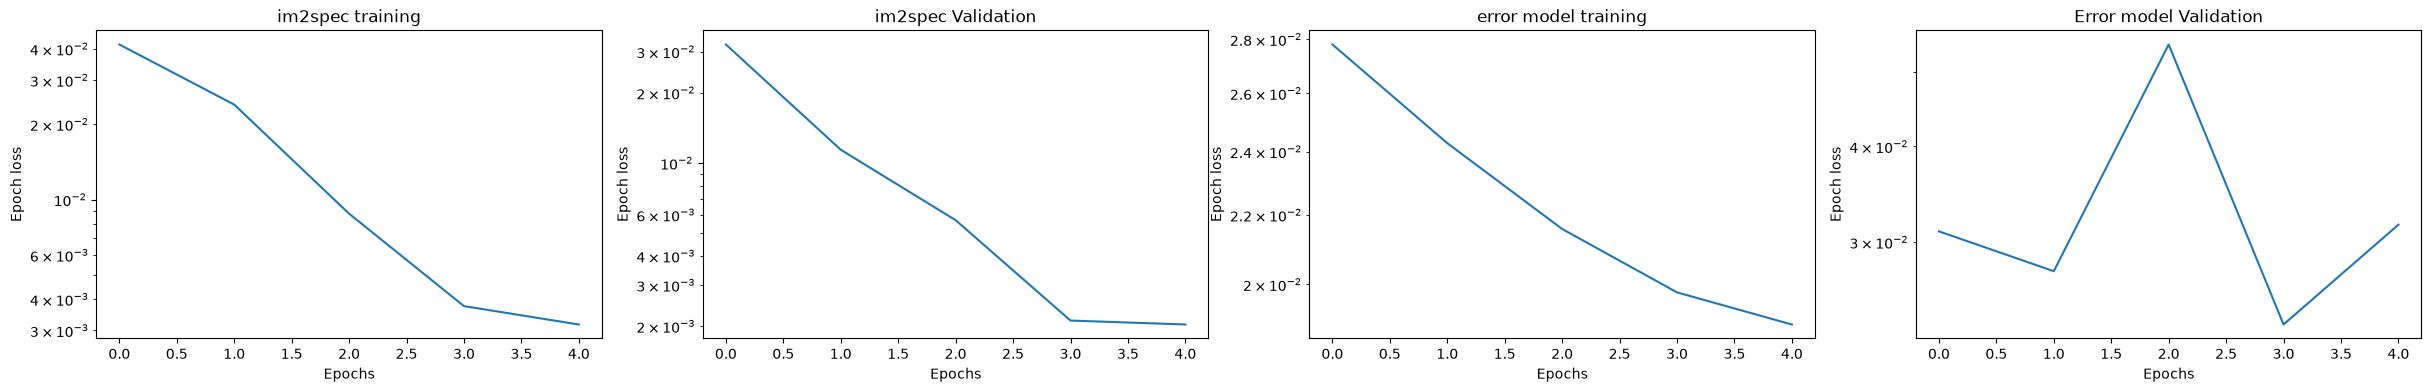


Testing with test size: 0.7000000000000001
Augmented images shape: (5728, 32, 32), Augmented spectra shape: (5728, 121), Augmented coordinates shape: (5728, 3)
Augmented images shape: (2464, 32, 32), Augmented spectra shape: (2464, 121), Augmented coordinates shape: (2464, 3)


 20%|██        | 1/5 [00:49<03:19, 49.76s/it, train_loss=0.0419, val_loss=0.0322]

SWA triggered at epoch 0


100%|██████████| 5/5 [04:58<00:00, 59.79s/it, train_loss=0.0024, val_loss=0.0020]


  Error targets train shape: (5728, 1)
  Error targets test shape: (2464, 1)
  Latent dimension for error model: 5


 20%|██        | 1/5 [00:41<02:45, 41.34s/it, train_loss=0.0249, val_loss=0.0257]

SWA triggered at epoch 0


100%|██████████| 5/5 [03:01<00:00, 36.36s/it, train_loss=0.0268, val_loss=0.0244]


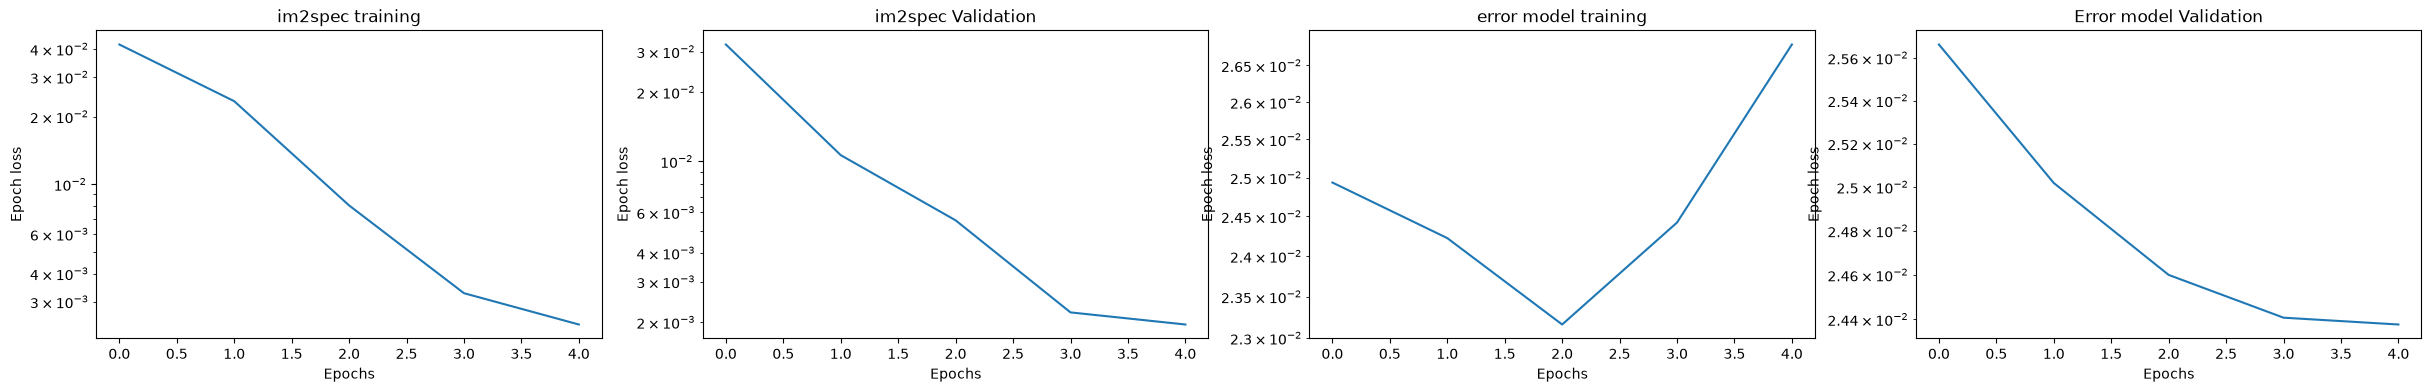

In [22]:
train_sizes = np.arange(0.1, 1, 0.3)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
in_dim = images[0].shape  # Input dimensions (image height and width)
out_dim = len(spectra[0])  # Output dimensions (spectra length)



im2spec_train_losses = []
im2spec_val_losses = []
im2spec_test_losses = []

error_train_losses = []
error_val_losses = []
error_test_losses = []


# These are renamed as errrors - not losses!
im2spec_test_mismatches = []
pred_error_test = []

for ts in train_sizes:



    print(f"\nTesting with test size: {ts}")

    #original_images, original_spectra, original_coordinates = paired_images_spectra_1(full_image, cits_obj, hyperspectra, window_size = WS, coordinate_step = 15, image_norm=False, spectra_norm = False)
    images_train_ts, images_test_ts, spectra_train_ts, spectra_test_ts = split_augment(ts, 
                                                                                     images_all, 
                                                                                     spectra_all, 
                                                                                     swap_coordinates_all, 
                                                                                     WS_init, 
                                                                                     WS, 
                                                                                     d_WS, 
                                                                                     append_image_type,
                                                                                     random_state = 42)


    if images_train_ts.shape[0] == 0 or images_test_ts.shape[0] == 0:
        print(f"Skipping test size {ts} due to insufficient training data.")
        continue

    # Train im2spec model on this train/test split
    # device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    imspec_model_ts = get_model(model_type, in_dim, out_dim, latent_dim=latent_dim, device=device)

    #imspec_model_ts = im2spec(feature_size=in_dim, target_size=out_dim, latent_dim=3).to(device)

    impsec_training_dataset_ts = TensorDataset(
        torch.tensor(images_train_ts, dtype=torch.float32),
        torch.tensor(spectra_train_ts, dtype=torch.float32),
    )
    impsec_val_dataset_ts = TensorDataset(
        torch.tensor(images_test_ts, dtype=torch.float32),
        torch.tensor(spectra_test_ts, dtype=torch.float32),
    )

    im2spec_model_ts, im2spec_train_loss_ts, im2spec_val_loss_ts = train_model(
        imspec_model_ts,
        impsec_training_dataset_ts,
        n_batches=6,
        lr=1e-3,
        patience=10,
        n_epochs=n_epochs_im2spec,
        partial_train= False,
        val_dataset = impsec_val_dataset_ts,
        use_swa = use_swa,
        last_swa_epochs = last_swa_epochs
    )


    im2spec_train_losses.append(im2spec_train_loss_ts)
    im2spec_val_losses.append(im2spec_val_loss_ts)

    imspec_model_ts.eval()
    with torch.no_grad():
        x_test_ts = torch.tensor(images_test_ts, dtype=torch.float32, device=device)
        y_test_ts = torch.tensor(spectra_test_ts, dtype=torch.float32, device=device)
        test_pred_ts = imspec_model_ts.predict(x_test_ts)
        im2spec_test_loss_ts = torch.nn.functional.mse_loss(test_pred_ts, y_test_ts).item()
    im2spec_test_losses.append(im2spec_test_loss_ts)

    # Train error model
    error_mean_ts, _, _ = err_estimation(imspec_model_ts, images_train_ts, spectra_train_ts, error_type=error_type)
    error_targets_ts = error_mean_ts.astype(np.float32).reshape(-1, 1)
    error_norm = Norm_0to1(data=error_targets_ts)
    normed_error_targets_ts = error_norm.normalize()

    # Add error estimation for the test set
    error_mean_test_ts, _, _ = err_estimation(imspec_model_ts, images_test_ts, spectra_test_ts, error_type=error_type)
    error_targets_test_ts = error_mean_test_ts.astype(np.float32).reshape(-1, 1)

    print(f"  Error targets train shape: {error_targets_ts.shape}")
    print(f"  Error targets test shape: {error_targets_test_ts.shape}")

    latent_dim_ts = imspec_model_ts.encoder(torch.tensor(images[:1], dtype=torch.float32, device=device).unsqueeze(1)).shape[1]
    print(f"  Latent dimension for error model: {latent_dim_ts}")
    error_model_ts = CustomDecoder(encoder=imspec_model_ts.encoder, embed_dim=latent_dim_ts, target_size=1).to(device)

    error_training_dataset_ts = TensorDataset(
        torch.tensor(images_train_ts, dtype=torch.float32),
        torch.tensor(normed_error_targets_ts, dtype=torch.float32),
    )

    error_model_ts, error_train_loss_ts, error_val_loss_ts = train_model(
        error_model_ts,
        error_training_dataset_ts,
        n_batches=6,
        lr=1e-3,
        patience=10,
        n_epochs=n_epochs_error,
        partial_train=True,
        use_swa = use_swa,
        last_swa_epochs = last_swa_epochs
    )

    plot_training_loss([im2spec_train_loss_ts], [im2spec_val_loss_ts], error_train_loss_ts, error_val_loss_ts)


    # Errors predicted by the error model on the test set
    # These are normalized errors, so we need to denormalize them to compare with the actual errors    
    norm_pred_errors_test = predict_spectra(error_model_ts, images_test_ts, ensemble=False)
    pred_errors_test = error_norm.denormalize(norm_pred_errors_test)

    # Append all losses to the lists for box plotting
    error_train_losses.append(error_train_loss_ts)
    error_test_losses.append(error_mean_test_ts)  # This is estimated from the im2spec model using err_estimation on test set
    error_val_losses.append(error_val_loss_ts) 


    # Append the im2spec test mismatches and predicted errors for later analysis
    im2spec_test_mismatches.append(error_mean_test_ts)
    pred_error_test.append(pred_errors_test)

    

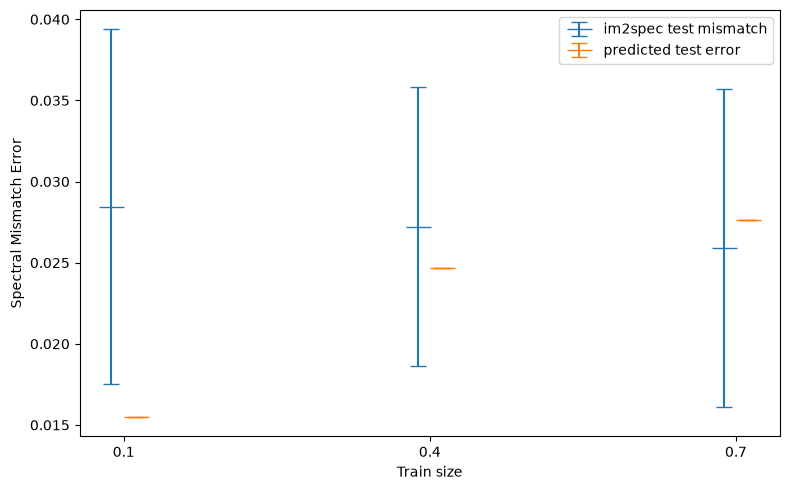

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Mean and standard deviation of im2spec test losses
mean_im2spec_test_errors = [np.mean(errors) for errors in im2spec_test_mismatches]
std_im2spec_test_errors = [np.std(errors) for errors in im2spec_test_mismatches]

# Mean and standard deviation of predicted test errors
mean_pred_error_test = [np.mean(errors) for errors in pred_error_test]
std_pred_error_test = [np.std(errors) for errors in pred_error_test]

# X positions
# x = np.arange(len(mean_im2spec_test_errors))
x = np.array(train_sizes)  # Use train sizes as x-axis values
offset = 0.012

plt.figure(figsize=(8, 5))

# Metric 1: im2spec test mismatch
plt.errorbar(
    x - offset,
    mean_im2spec_test_errors,
    yerr=std_im2spec_test_errors,
    fmt="_",
    markersize=18,
    capsize=6,
    linestyle="none",
    label="im2spec test mismatch",
)

# Metric 2: predicted test error
plt.errorbar(
    x + offset,
    mean_pred_error_test,
    yerr=std_pred_error_test,
    fmt="_",
    markersize=18,
    capsize=6,
    linestyle="none",
    label="predicted test error",
)

plt.xlabel("Train size")
plt.ylabel("Spectral Mismatch Error")
plt.xticks(x)
plt.legend()
plt.tight_layout()
plt.show()



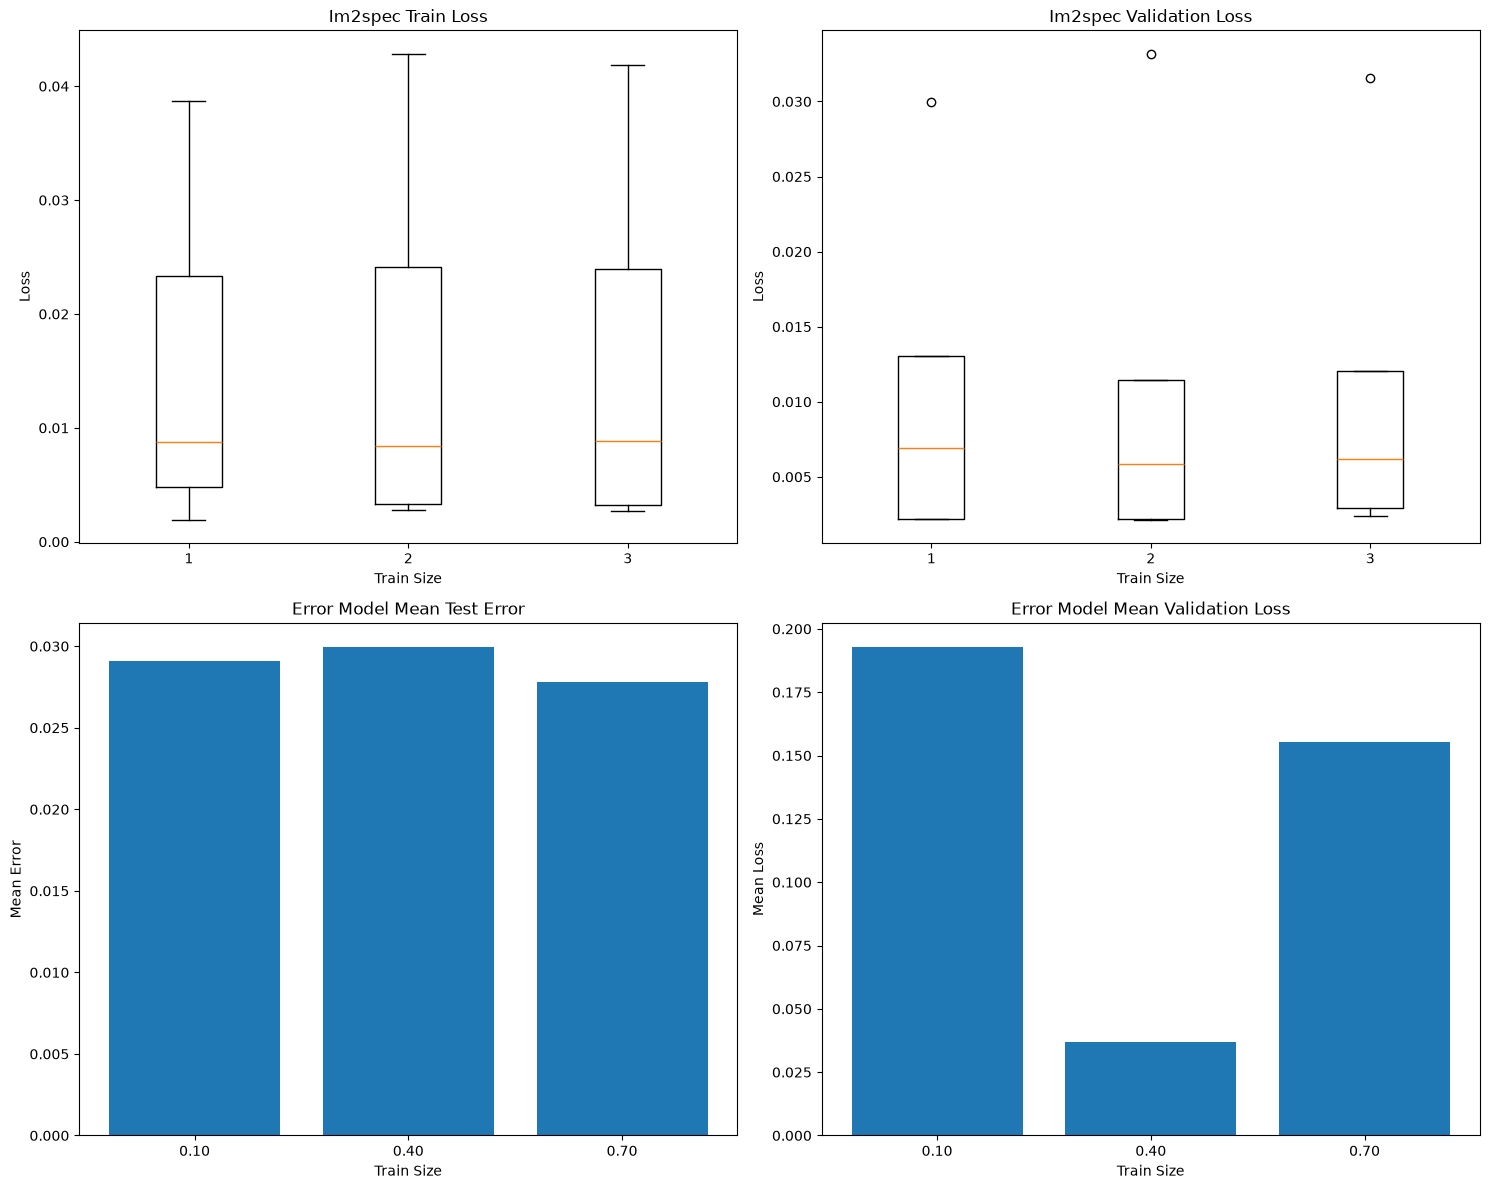

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate the mean validation loss for the error model for bar plotting
mean_error_val_losses = [np.mean(losses) for losses in error_val_losses]

# Calculate mean of error_test_losses for bar plotting
mean_error_test_losses_per_train_size = [np.mean(err_arr) for err_arr in error_test_losses]

# Plot charts on a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Im2spec Train Loss Box Plot
axes[0, 0].boxplot(im2spec_train_losses)
axes[0, 0].set_title("Im2spec Train Loss")
axes[0, 0].set_xlabel("Train Size")
axes[0, 0].set_ylabel("Loss")

# Im2spec Validation Loss Box Plot
axes[0, 1].boxplot(im2spec_val_losses)
axes[0, 1].set_title("Im2spec Validation Loss")
axes[0, 1].set_xlabel("Train Size")
axes[0, 1].set_ylabel("Loss")

# Error Model Mean Test Error Bar Chart
axes[1, 0].bar([f"{ts:.2f}" for ts in train_sizes], mean_error_test_losses_per_train_size)
axes[1, 0].set_title("Error Model Mean Test Error")
axes[1, 0].set_xlabel("Train Size")
axes[1, 0].set_ylabel("Mean Error")

# Error Model Mean Validation Loss Bar Chart
axes[1, 1].bar([f"{ts:.2f}" for ts in train_sizes], mean_error_val_losses)
axes[1, 1].set_title("Error Model Mean Validation Loss")
axes[1, 1].set_xlabel("Train Size")
axes[1, 1].set_ylabel("Mean Loss")

plt.tight_layout()
plt.show()